In [1]:
import os
import cv2
import matplotlib.pyplot as plt
import random

In [2]:
import os
import cv2
import matplotlib.pyplot as plt

def preprocess_image_to_160x160(img_path):
    """
    Loads an image, removes plot-like borders, and returns a 160x160
    center-cropped RGB image.
    """
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Image not found at: {img_path}")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_cropped = img[4:-47, 94:]

    h, w, _ = img_cropped.shape
    crop_size = 162
    start_y = (h - crop_size) // 2
    start_x = (w - crop_size) // 2
    cropped_162 = img_cropped[start_y:start_y + crop_size, start_x:start_x + crop_size]
    final_crop = cropped_162[1:-1, 1:-1]

    return final_crop  

def process_and_save_all_images(source_folder, dest_folder):
    """
    Applies preprocessing to all images in a folder and saves to a new destination.
    """
    os.makedirs(dest_folder, exist_ok=True)

    for filename in os.listdir(source_folder):
        if filename.lower().endswith((".png", ".jpg", ".jpeg")):
            img_path = os.path.join(source_folder, filename)
            try:
                processed_img = preprocess_image_to_160x160(img_path)
                dest_path = os.path.join(dest_folder, filename)
                cv2.imwrite(dest_path, processed_img)  
                print(f"Saved: {dest_path}")
            except Exception as e:
                print(f"Error with {filename}: {e}")


In [3]:
# Process both folders
process_and_save_all_images("benign", "benign_preprocessed")
process_and_save_all_images("pulse", "pulse_preprocessed")
process_and_save_all_images("single_tone", "single_tone_preprocessed")
process_and_save_all_images("wideband", "wideband_preprocessed")


Saved: benign_preprocessed/20250417_9395.png
Saved: benign_preprocessed/20250412_192.png
Saved: benign_preprocessed/20250417_8106.png
Saved: benign_preprocessed/20250417_3983.png
Saved: benign_preprocessed/20250417_5628.png
Saved: benign_preprocessed/20250417_4848.png
Saved: benign_preprocessed/20250417_4696.png
Saved: benign_preprocessed/20250417_1081.png
Saved: benign_preprocessed/20250417_8859.png
Saved: benign_preprocessed/20250417_2148.png
Saved: benign_preprocessed/20250417_6860.png
Saved: benign_preprocessed/20250417_6132.png
Saved: benign_preprocessed/20250417_2839.png
Saved: benign_preprocessed/20250417_2048.png
Saved: benign_preprocessed/20250417_4131.png
Saved: benign_preprocessed/20250417_4536.png
Saved: benign_preprocessed/20250417_8553.png
Saved: benign_preprocessed/20250417_8784.png
Saved: benign_preprocessed/20250417_4170.png
Saved: benign_preprocessed/20250417_2831.png
Saved: benign_preprocessed/20250417_8082.png
Saved: benign_preprocessed/20250417_1163.png
Saved: beni

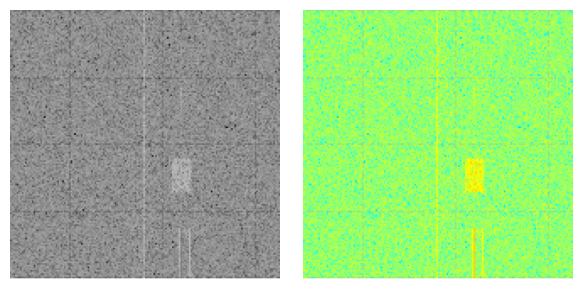

In [10]:

# Load image
img_path = os.path.join("jamming_preprocessed", "20250412_120.png")
img = cv2.imread(img_path)

# Convert to RGB and Grayscale
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Plot side by side
plt.figure(figsize=(6, 3))

# Grayscale
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.axis('off')

# RGB
plt.subplot(1, 2, 2)
plt.imshow(img_rgb)
plt.axis('off')

plt.tight_layout()
plt.show()


In [12]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats
                         std=[0.229, 0.224, 0.225])
])

In [ ]:
from torchvision.datasets import ImageFolder

dataset = ImageFolder('dataset_root', transform=transform)
print(dataset.class_to_idx) 

{'benign_preprocessed': 0, 'jamming_preprocessed': 1}


In [ ]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])


In [16]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)


In [17]:
from torchvision import models
import torch.nn as nn

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 2)  # 2 classes: benign and jamming


/home/ioannis/.local/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ioannis/.local/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/ioannis/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 109MB/s] 


In [22]:
import torch

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print("Using device:", device)


criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


Using device: cuda:1


In [23]:
num_epochs = 10  

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)              
        loss = criterion(outputs, labels)   
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")


Epoch 1/10, Loss: 0.0003
Epoch 2/10, Loss: 0.0002
Epoch 3/10, Loss: 0.0011
Epoch 4/10, Loss: 0.0001
Epoch 5/10, Loss: 0.0001
Epoch 6/10, Loss: 0.0000
Epoch 7/10, Loss: 0.0000
Epoch 8/10, Loss: 0.0000
Epoch 9/10, Loss: 0.0002
Epoch 10/10, Loss: 0.0000


In [24]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"Validation Accuracy: {100 * correct / total:.2f}%")


Validation Accuracy: 100.00%
